In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

### Import Database/Data

In [3]:
conn = sqlite3.connect(r"C:\Users\knayl\Downloads\customer_churn.db")

sql_query = """
    SELECT name FROM sqlite_master
    WHERE type='table'
"""

tables = pd.read_sql(sql_query, conn)

for table_name in tables['name']:
    df = pd.read_sql(f"SELECT * FROM {table_name}", conn)
    globals()[f"df_{table_name}"] = df
    print(f"Created dataframe: df_{table_name}")


Created dataframe: df_db_customer
Created dataframe: df_db_subscription
Created dataframe: df_db_support


In [4]:
print(tables)

              name
0      db_customer
1  db_subscription
2       db_support


In [5]:
print(tables['name'].tolist())

['db_customer', 'db_subscription', 'db_support']


### Data Cleaning

Customer Table

In [8]:
df_db_customer.head(5)

,customerid,name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,None,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,None,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None


In [9]:
df_db_customer.tail()

,customerid,name,country,state,gender,dob,interests,pincode
16,0020-JDNXP,rikim,India,Meghalaya,Female,1994-08-19 00:00:00,None,None
17,0021-IKXGC,vishakha,India,Rajasthan,Female,2000-09-02 00:00:00,None,None
18,0022-TCJCI,raghvendra,India,Telangana,Male,1983-12-30 00:00:00,None,None
19,0023-HGHWL,rishabh,India,Uttar Pradesh,Men,1991-05-14 00:00:00,None,None
20,0023-UYUPN,sudevi,India,Maharashtra,Women,1977-10-06 00:00:00,None,None


In [10]:
df_db_customer.shape

(21, 8)

In [11]:
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     object
 1   name        21 non-null     object
 2   country     18 non-null     object
 3   state       21 non-null     object
 4   gender      21 non-null     object
 5   dob         21 non-null     object
 6   interests   4 non-null      object
 7   pincode     0 non-null      object
dtypes: object(8)
memory usage: 1.4+ KB


1.Rename col - name  
2.drop columns - interests, pincode   
3.Change dob datatype to date  
4.Data Standardization - gender col  
5.Fix Missing values in country column  

In [13]:
df_db_customer.rename(columns = {'name' : 'customer_name'},inplace=True)
df_db_customer.head(3)

,customerid,customer_name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,None,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None


In [14]:
df_db_customer.drop(columns=['interests','pincode'],inplace=True)
df_db_customer.head(3)

,customerid,customer_name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00


In [15]:
df_db_customer['dob']= pd.to_datetime(df_db_customer['dob'])

In [16]:
df_db_customer['gender']=df_db_customer['gender'].replace({'Men':'Male','Women':'Female'})

In [17]:
df_db_customer['gender'].unique()

array(['Male', 'Female'], dtype=object)

In [18]:
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob
5,0013-MHZWF,durga,None,Delhi,Female,1988-12-10
8,0015-UOCOJ,maya,None,Kathmandu,Female,1985-07-07
12,0018-NYROU,chitra,None,Telangana,Female,2004-12-01


In [19]:
state_country_mapping=df_db_customer.dropna(subset=['country']).set_index('state')['country'].to_dict()
df_db_customer['country']=df_db_customer['country'].fillna(df_db_customer['state'].map(state_country_mapping))

In [20]:
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob


In [21]:
df_db_customer.describe()

,dob
count,21
mean,1989-08-26 12:34:17.142857088
min,1976-09-21 00:00:00
25%,1982-04-12 00:00:00
50%,1990-05-05 00:00:00
75%,1995-11-23 00:00:00
max,2004-12-01 00:00:00


Subscription Table

In [23]:
df_db_subscription.head(5)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,None,None,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,None,None,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,None,None,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [24]:
df_db_subscription.tail(5)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
16,0020-JDNXP,2022-01-19,Organic,2024-01-19,Premium,Annual,None,None,20.99,550,62
17,0021-IKXGC,2021-07-07,Paid,2025-07-07,Standard,Annual,None,None,13.99,840,27
18,0022-TCJCI,2023-09-14,Refferal,2024-09-14,Basic,Monthly,2024-09-14,Forgot to cancel trial,16.99,42,99
19,0023-HGHWL,2020-06-23,Organic,2025-06-23,Premium,Annual,None,None,22.99,1955,7
20,0023-UYUPN,2022-12-31,Paid,2025-12-31,Standard,Monthly,None,None,13.99,790,47


In [25]:
df_db_subscription.shape

(21, 11)

In [26]:
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     object 
 1   subscription_start_date  21 non-null     object 
 2   subscription_type        21 non-null     object 
 3   renewal_date             21 non-null     object 
 4   plan_type                21 non-null     object 
 5   contract_type            21 non-null     object 
 6   cancellation_date        6 non-null      object 
 7   cancellation_reason      6 non-null      object 
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 1.9+ KB


1.Change Format of the columns (subscription_start_date,renewal_date,cancellation_date) to Date 


In [28]:
df_db_subscription['subscription_start_date']=pd.to_datetime(df_db_subscription['subscription_start_date'])

In [29]:
df_db_subscription['renewal_date']=pd.to_datetime(df_db_subscription['renewal_date'])

In [30]:
df_db_subscription['cancellation_date']=pd.to_datetime(df_db_subscription['cancellation_date'])

In [31]:
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     object        
 1   subscription_start_date  21 non-null     datetime64[ns]
 2   subscription_type        21 non-null     object        
 3   renewal_date             21 non-null     datetime64[ns]
 4   plan_type                21 non-null     object        
 5   contract_type            21 non-null     object        
 6   cancellation_date        6 non-null      datetime64[ns]
 7   cancellation_reason      6 non-null      object        
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
dtypes: datetime64[ns](3), float64(1), int64(2), object(5)
memory usage: 1.9+ KB


In [32]:
df_db_subscription['subscription_type'].unique()

array(['Refferal', 'Paid', 'Organic'], dtype=object)

In [33]:
df_db_subscription['plan_type'].unique()

array(['Standard', 'Premium', 'Basic'], dtype=object)

In [34]:
df_db_subscription['contract_type'].unique()

array(['Annual', 'Monthly'], dtype=object)

In [35]:
df_db_subscription['cancellation_reason'].unique()

array([None, 'Switched to competitor', 'Too expensive',
       'Not enough content', 'Poor streaming quality',
       'Forgot to cancel trial'], dtype=object)

In [36]:
df_db_subscription.describe()

,subscription_start_date,renewal_date,cancellation_date,monthly_charges,cltv,churn_score
count,21,21,6,21.000000,21.000000,21.000000
mean,2021-11-20 18:17:08.571428608,2025-02-15 17:08:34.285714176,2024-08-06 16:00:00,18.847143,823.523810,43.285714
min,2019-05-10 00:00:00,2024-01-05 00:00:00,2024-02-28 00:00:00,6.990000,42.000000,3.000000
25%,2020-10-09 00:00:00,2024-08-25 00:00:00,2024-06-03 00:00:00,12.990000,240.000000,14.000000
50%,2022-01-19 00:00:00,2025-04-03 00:00:00,2024-09-12 00:00:00,13.990000,640.000000,34.000000
75%,2022-12-31 00:00:00,2025-07-07 00:00:00,2024-10-19 06:00:00,20.990000,1150.000000,76.000000
max,2023-09-14 00:00:00,2025-12-31 00:00:00,2024-11-15 00:00:00,92.990000,2185.000000,99.000000
std,NaN,NaN,NaN,17.754677,668.913195,32.292635


Customer Support

In [38]:
df_db_support.head(5)

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,None
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,None


In [39]:
df_db_support.tail(5)

,customerid,complaint_date,escalations,csat_score,col_1,comment
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,None
5,0017-IUDMW,2024-04-10 00:00:00,Y,25,None,None
6,0019-EFAEP,2024-09-27 00:00:00,Y,30,None,None
7,0022-TCJCI,2024-09-13 00:00:00,Y,10,None,None
8,0022-TCJCI,2024-09-14 00:00:00,N,90,None,received refund


In [40]:
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      object
 1   complaint_date  9 non-null      object
 2   escalations     9 non-null      object
 3   csat_score      9 non-null      int64 
 4   col_1           0 non-null      object
 5   comment         4 non-null      object
dtypes: int64(1), object(5)
memory usage: 564.0+ bytes


1.Change complaint_date col datatype to Date  
2. Drop last two columns

In [42]:
df_db_support['complaint_date']=pd.to_datetime(df_db_support['complaint_date'])

In [43]:
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      9 non-null      object        
 1   complaint_date  9 non-null      datetime64[ns]
 2   escalations     9 non-null      object        
 3   csat_score      9 non-null      int64         
 4   col_1           0 non-null      object        
 5   comment         4 non-null      object        
dtypes: datetime64[ns](1), int64(1), object(4)
memory usage: 564.0+ bytes


In [44]:
df_db_support['escalations'].unique()

array(['N', 'Y'], dtype=object)

In [45]:
df_db_support.drop(columns = ['col_1','comment'],inplace=True)

In [46]:
df_db_support.head(2)

,customerid,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28,N,60
1,0003-MKNFE,2024-08-28,Y,10


### Feature Engineering & Data Analysis

1.Create Churn Flag Column  
2.left join subscription , customer and support table  
3.df rows should be 21 , but it is showing 23. so there must be descripencies.  

In [49]:
df_db_subscription['Churn_Flag']=np.where(df_db_subscription['cancellation_date'].notna(),1,0)

In [50]:
df_db_subscription.head(2)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,Churn_Flag
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1


In [51]:
df = (df_db_subscription.merge(df_db_customer,on='customerid',how='left')
                  .merge(df_db_support,on='customerid',how='left'))

In [52]:
df.shape

(23, 20)

In [53]:
df_db_support.head(2)

,customerid,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28,N,60
1,0003-MKNFE,2024-08-28,Y,10


In [54]:
df_db_support['complaint_count']=df_db_support.groupby('customerid')['customerid'].transform('count')

In [55]:
df_db_support=df_db_support.sort_values('complaint_date').drop_duplicates('customerid',keep='last')

In [56]:
df = (df_db_subscription.merge(df_db_customer,on='customerid',how='left')
                  .merge(df_db_support,on='customerid',how='left'))

In [57]:
df.shape

(21, 21)

### Data Analysis

In [59]:
df.to_csv('exported_churn_data.csv',index=False)

In [60]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'Churn_Flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count'],
      dtype='object')

In [62]:
churn_rate = df['Churn_Flag'].mean() * 100
print("Churn Rate = ",round(churn_rate,2),"%")

Churn Rate =  28.57 %


In [64]:
retention_rate = 100 - churn_rate
print("Retention Rate = ",round(retention_rate,2),"%")

Retention Rate =  71.43 %


In [66]:
## Churn by Plan Type
churn_by_plan = df.groupby('plan_type')['Churn_Flag'].mean().mul(100).round(2).reset_index(name='churn_rate_pct')
churn_by_plan

,plan_type,churn_rate_pct
0,Basic,60.00
1,Premium,14.29
2,Standard,22.22


In [68]:
## Churn by state
churn_by_state = df.groupby('state').agg(
    Churn_rate_pct=("Churn_Flag", lambda x: x.mean() * 100),
    Total_Revenue=("monthly_charges", "sum"),
    Count_of_users =("customerid","count")
)

churn_by_state

,Churn_rate_pct,Total_Revenue,Count_of_users
state,,,
Delhi,25.000000,52.96,4
Karnataka,100.000000,20.98,2
Kathmandu,0.000000,20.98,2
Maharashtra,0.000000,50.97,3
Meghalaya,66.666667,42.97,3
Nagaland,0.000000,22.99,1
Rajasthan,0.000000,36.98,2
Telangana,50.000000,30.98,2
Uttar Pradesh,0.000000,115.98,2


In [92]:
## Churn by subscription
churn_by_subscription_type = df.groupby('subscription_type').agg(
    Churn_rate_pct=("Churn_Flag", lambda x: x.mean() * 100),
    Total_Revenue=("monthly_charges", "sum"),
    Count_of_users =("customerid","count")
)

churn_by_subscription_type

,Churn_rate_pct,Total_Revenue,Count_of_users
subscription_type,,,
Organic,0.000000,145.91,9
Paid,16.666667,174.94,6
Refferal,83.333333,74.94,6


In [70]:
df['age'] = (pd.Timestamp.today() - df['dob']).dt.days / 365.25

In [74]:
## ARPU (Average Revenue Per User)
arpu=df['monthly_charges'].mean()
print("ARPU = ",round(arpu,2))

ARPU =  18.85


In [76]:
## Average Customer Tenure
today=pd.Timestamp.today()

df['tenure_days']=np.where(df['cancellation_date'].notna(),(df['cancellation_date']-df['subscription_start_date']).dt.days,
                           (today-df['subscription_start_date']).dt.days)

avg_tenure = df['tenure_days'].mean()
print("Average Tenure = ",round(avg_tenure))

Average Tenure =  1544


In [78]:
## Revenue at Risk : Revenue lost from churned users
revenue_at_risk = df.loc[df['Churn_Flag']==1,'monthly_charges'].sum()

print("Revenue at Risk (Rs 'K') = ",round(revenue_at_risk,2))

Revenue at Risk (Rs 'K') =  73.94


In [90]:
## Escalation Rate 
escalation_rate = (df['escalations']=='Y').mean() * 100
print("Escalation Rate = ",round(escalation_rate,2),"%")

Escalation Rate =  19.05 %


In [94]:
## Average Complaint per User
avg_complaints = df['complaint_count'].sum()/df['customerid'].nunique()
print("Average Complaints per User = ",round(avg_complaints,2))

Average Complaints per User =  0.43


In [96]:
## Correlation Escalation vs Churn

df['escalations'] = np.where(df['escalations']=='Y',1,0)  ## encoding string to int type
corr_df = df[['escalations','Churn_Flag']].dropna()

correlation = corr_df['escalations'].corr(df['Churn_Flag'])
print("Correlation between escalation vs churn is = ",round(correlation,2))

Correlation between escalation vs churn is =  0.77


In [98]:
## churn Risk (based on churn score)

conditions = [
    (df['churn_score'] < 50),
    (df['churn_score'] >= 50) & (df['churn_score'] < 70),
    (df['churn_score'] >= 70)
]

choices = ['Low','Medium','High']

df['churn_risk']=np.select(conditions,choices,default='Unknown')

In [102]:
df[['churn_score','churn_risk']].head(3)

,churn_score,churn_risk
0,12,Low
1,91,High
2,34,Low


### Data Visualization

In [112]:
## making copy of main data (df)
df_visual = df.copy()

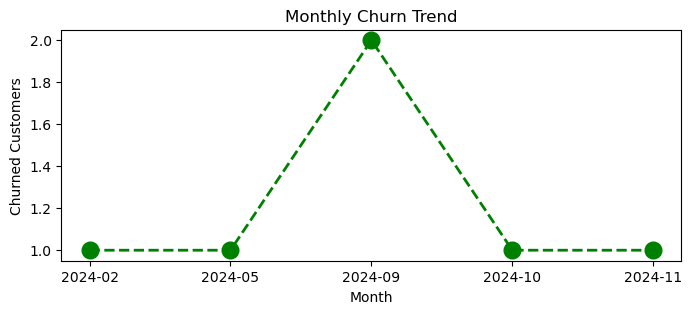

In [122]:
## Monthly Churn Trend

df_visual['cancellation_month'] = df_visual['cancellation_date'].dt.to_period('M')
churn_trend = df_visual[df_visual['Churn_Flag']==1].groupby('cancellation_month').size()

plt.figure(figsize=(8,3))
plt.plot(churn_trend.index.astype('str'),churn_trend.values,color='green', marker='o', linestyle='dashed',linewidth=2, markersize=12)

plt.title("Monthly Churn Trend")
plt.xlabel("Month")
plt.ylabel("Churned Customers")
plt.show()

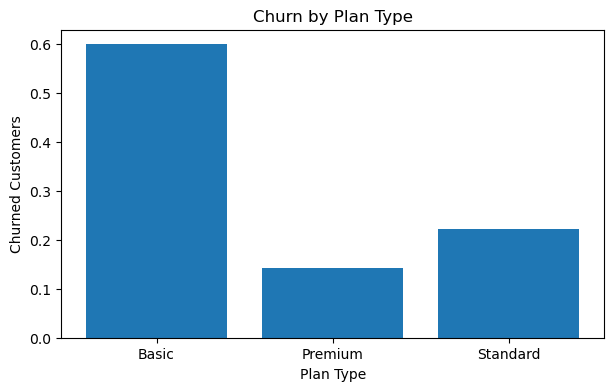

In [124]:
## Churn by Plan Type

churn_plan = df_visual.groupby('plan_type')['Churn_Flag'].mean()

plt.figure(figsize=(7,4))
plt.bar(churn_plan.index,churn_plan.values)

plt.title("Churn by Plan Type")
plt.xlabel("Plan Type")
plt.ylabel("Churned Customers")
plt.show()

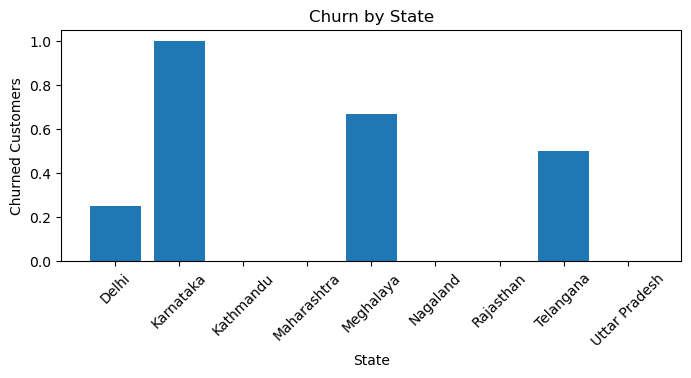

In [130]:
## Churn by States
churn_states = df_visual.groupby('state')['Churn_Flag'].mean()

plt.figure(figsize=(8,3))
plt.bar(churn_states.index,churn_states.values)

plt.title("Churn by State")
plt.xlabel("State")
plt.ylabel("Churned Customers")
plt.xticks(rotation=45)
plt.show()

In [132]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'Churn_Flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count', 'age',
       'tenure_days', 'churn_risk', 'cancellation_month'],
      dtype='object')

In [140]:
import warnings
warnings.filterwarnings("ignore")

In [142]:
##encoding the str type col to int type for heatmap --- However this is incorrect way of encoding
df_encode = df_visual[['plan_type', 'contract_type','churn_score','Churn_Flag','churn_risk','escalations']]

categoriacal_cols = ['plan_type', 'contract_type','churn_risk']

for col in categoriacal_cols:
    df_encode[col] = df_encode[col].astype('category').cat.codes

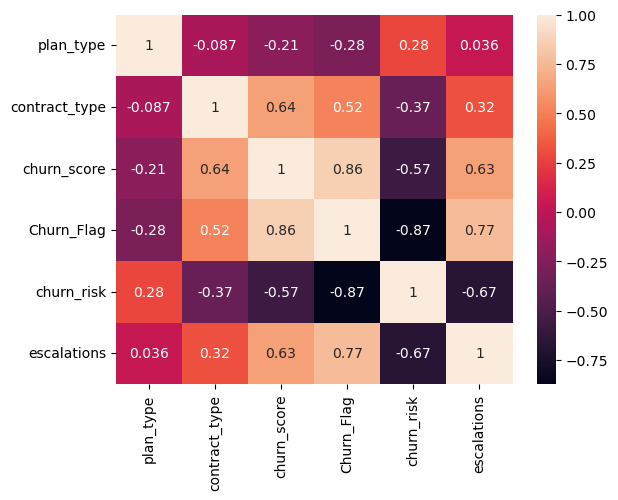

In [146]:
## Heatmap (correlation matrix)

sns.heatmap(df_encode.corr(),annot=True)

plt.show()

In [152]:
df_visual['churn_risk'].unique()

array(['Low', 'High', 'Medium'], dtype=object)

In [162]:
##encoding the str type col to int type for heatmap --- correct way of encoding
df_encode = df_visual[['plan_type', 'contract_type','churn_score','Churn_Flag','churn_risk','escalations']]

order_mappings = {'plan_type':['Basic','Standard','Premium'], 
                     'contract_type':['Monthly','Annual'],
                     'churn_risk':['Low','Medium','High']
                 }

for col , order in order_mappings.items():
    df_encode[col] = pd.Categorical(df_encode[col].astype('category'),categories=order,ordered=True).codes

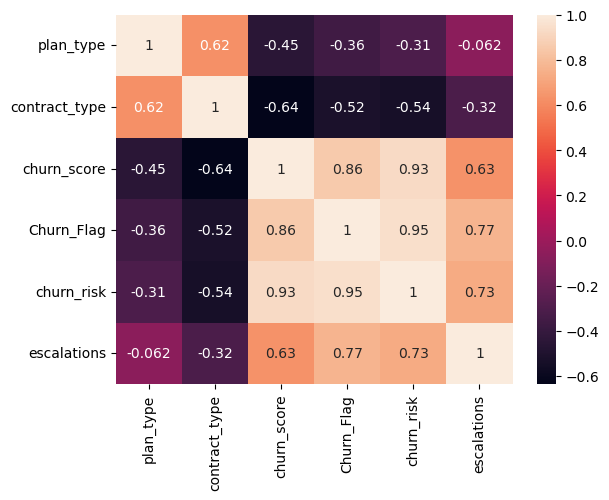

In [164]:
## Heatmap (correlation matrix)

sns.heatmap(df_encode.corr(),annot=True)

plt.show()

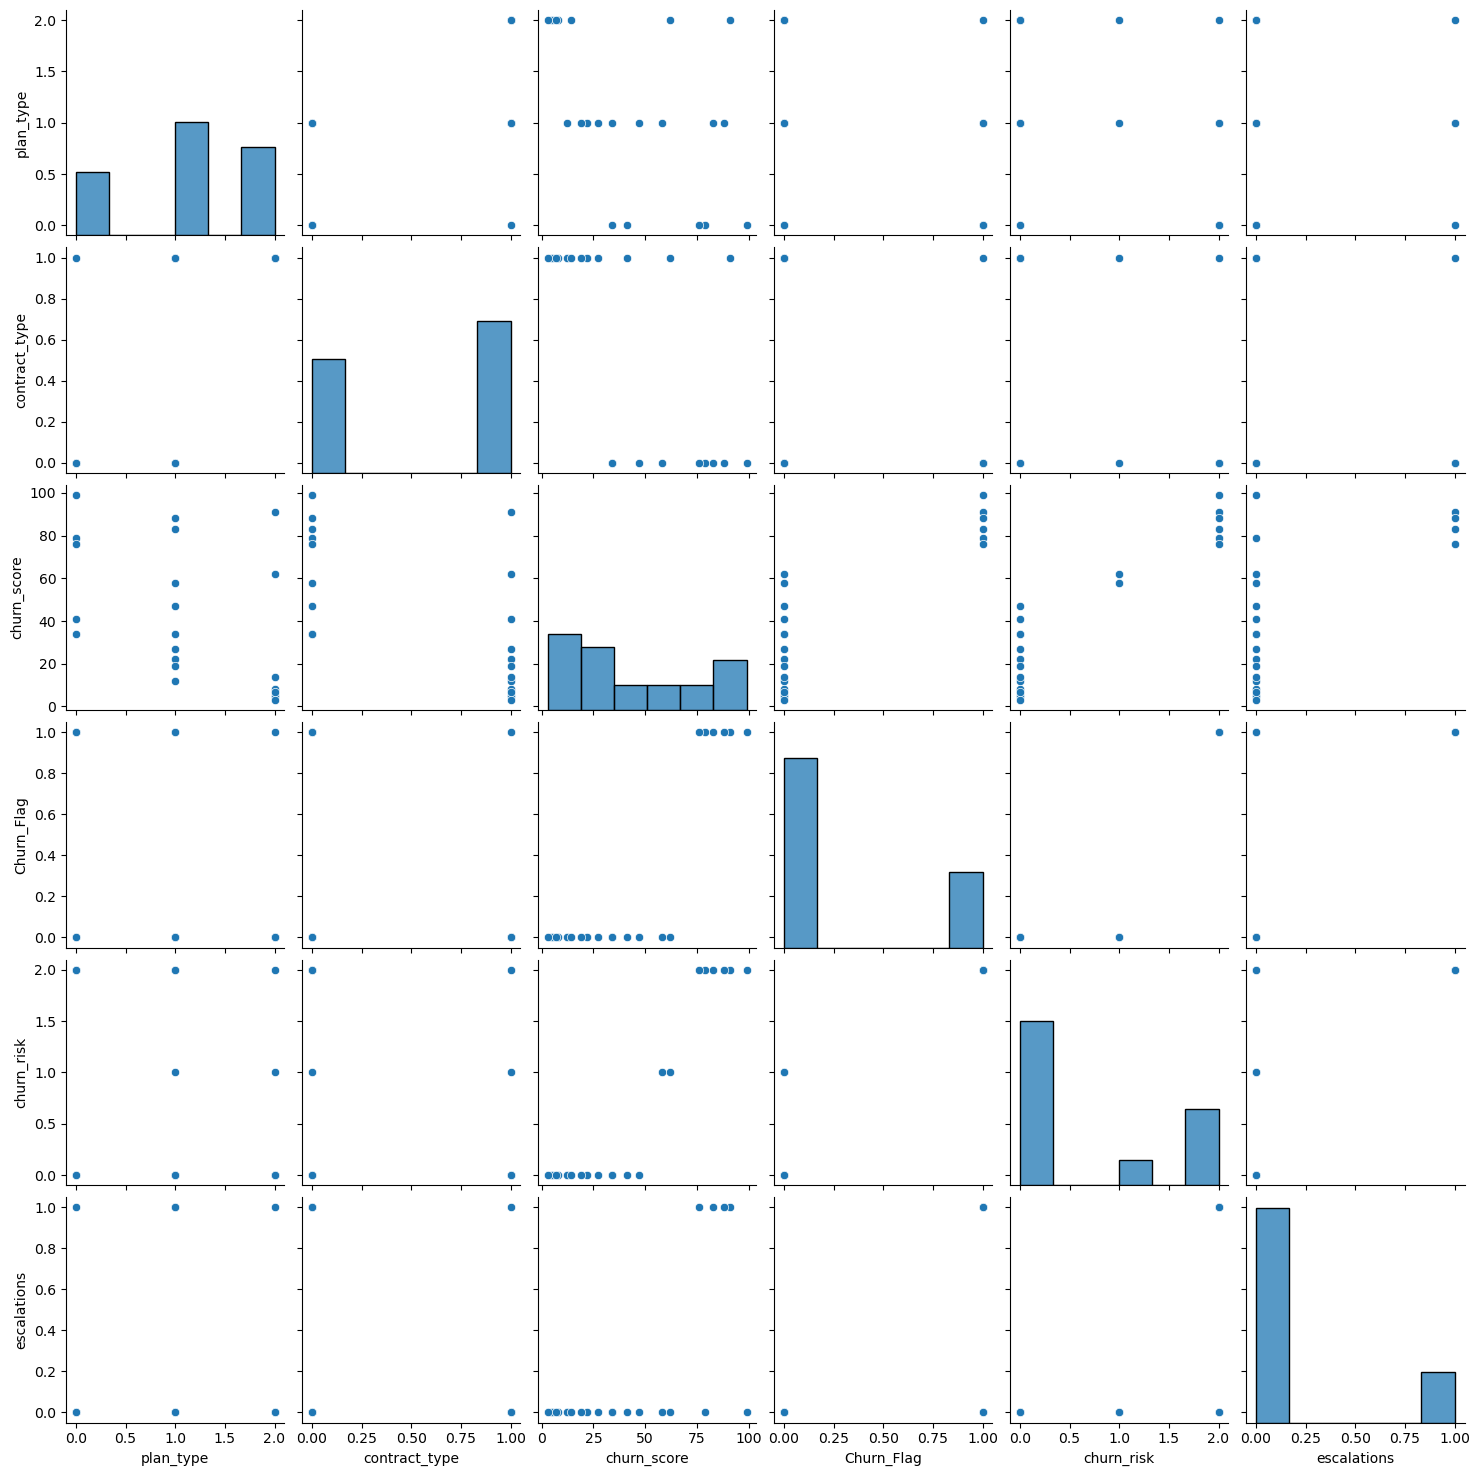

In [168]:
## Pairplot

sns.pairplot(df_encode)
plt.show()

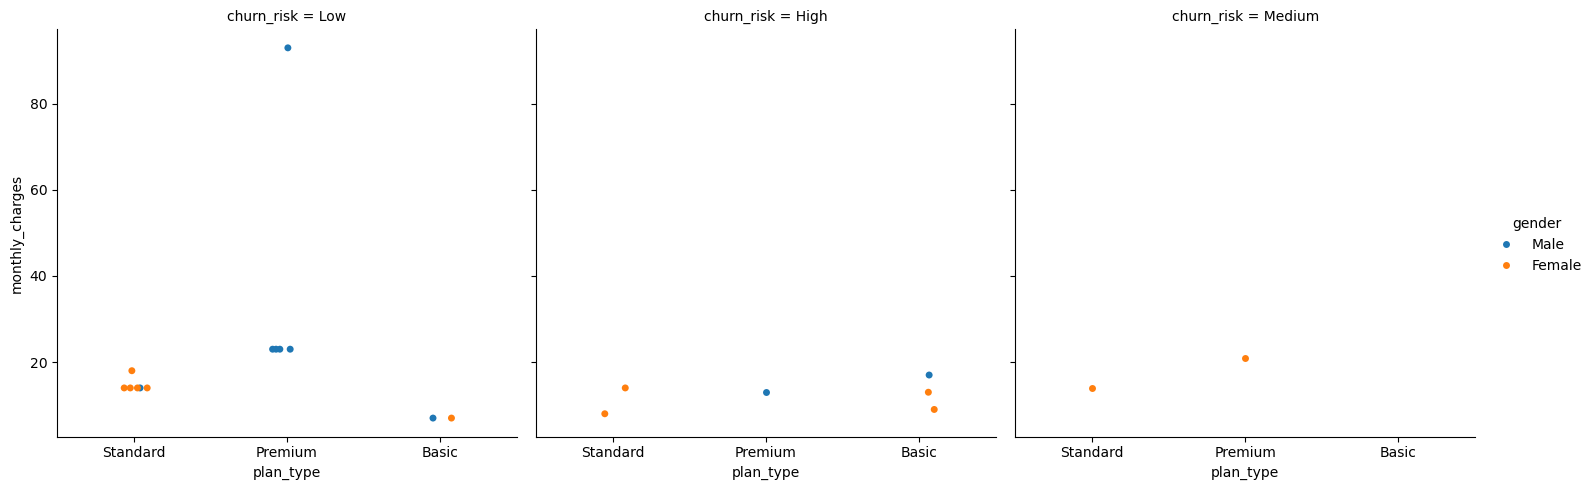

In [170]:
## Categorical Plot / Facegrid Plot - multi dimension comparison

sns.catplot(data=df_visual,
           x='plan_type',
           y='monthly_charges',
           hue='gender',
           col='churn_risk')

plt.show()

In [176]:
## Aggregated Table

pd.pivot_table(
    df_visual,
    index = 'plan_type',
    values = ['monthly_charges','customerid','Churn_Flag'],
    aggfunc = {
        'monthly_charges':'sum',
        'customerid':'nunique',
        'Churn_Flag': 'mean'
    }
)

,Churn_Flag,customerid,monthly_charges
plan_type,,,
Basic,0.600000,5,52.95
Premium,0.142857,7,218.93
Standard,0.222222,9,123.91
